# Main Report — Cross-Experiment Analysis

把 exp-4 (deep) 和 exp-5 (fast) 两条改进线放在同一幅报告里对比：双柱 / 阈值热图 / 胜负 2×2 / 因果堆叠 / Performance Profile / 收敛曲线。

In [1]:
import sys
sys.path.insert(0, '.')
from _style import *

CHART_DIR = Path('charts')
CHART_DIR.mkdir(exist_ok=True)

df4 = load_exp(EXP4_CSV)
df5 = load_exp(EXP5_CSV)

imp4 = per_instance(df4, 'deep-v6')
base4 = per_instance(df4, 'dual-deep')
m4 = pairwise(imp4, base4)

imp5 = per_instance(df5, 'fast-v19')
base5 = per_instance(df5, 'dual-fast')
m5 = pairwise(imp5, base5)

print('exp-4 merged:', len(m4), 'exp-5 merged:', len(m5))


exp-4 merged: 1074 exp-5 merged: 1080


## D1 总体 + 阈值

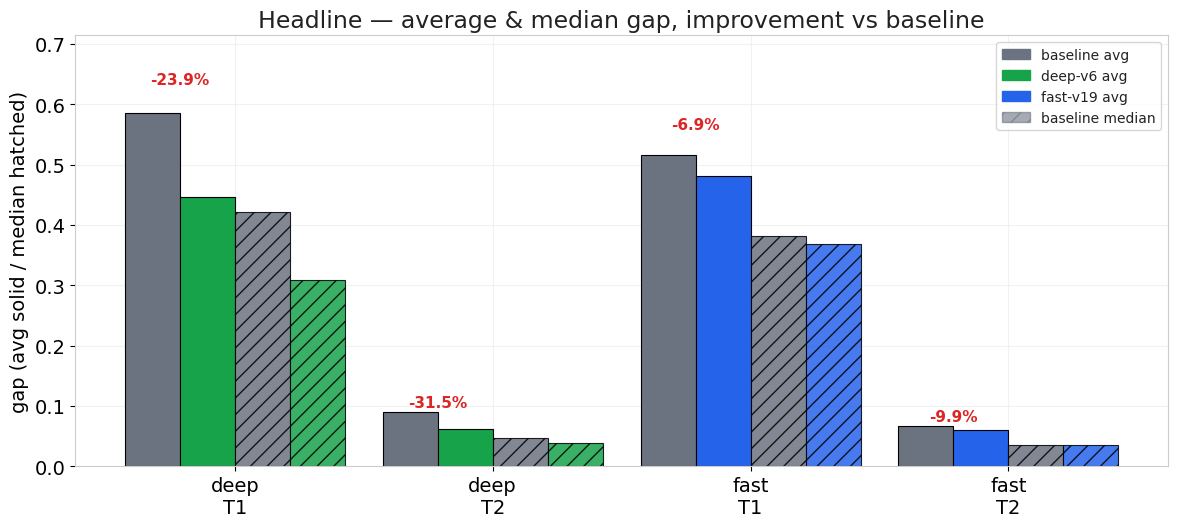

In [2]:
# ## M-01 — Headline avg + median gap (4 solvers × 2 datasets)
fig, ax = plt.subplots(figsize=(12, 5.5))

pairs = [
    ('dual-deep', 'deep-v6',  df4,  'deep',  GREEN),
    ('dual-fast', 'fast-v19', df5,  'fast',  BLUE),
]
x = np.arange(4) * 1.5  # 4 group positions (deepT1 deepT2 fastT1 fastT2)
w = 0.32
xs_base = []; xs_imp = []
group_pos = [0, 1, 2, 3]
labels = []
max_avg = 0
for bn, imn, dfx, fam, col in pairs:
    for i, d in enumerate(['T1', 'T2']):
        idx = (0 if fam == 'deep' else 2) + i
        sub_imp = dfx[(dfx.solver == imn) & (dfx.dataset == d)]
        sub_base = dfx[(dfx.solver == bn) & (dfx.dataset == d)]
        avg_b = sub_base.groupby('instance')['gap'].mean().mean()
        avg_i = sub_imp.groupby('instance')['gap'].mean().mean()
        med_b = sub_base.groupby('instance')['gap'].mean().median()
        med_i = sub_imp.groupby('instance')['gap'].mean().median()
        max_avg = max(max_avg, avg_b, avg_i)
        ax.bar(x[idx] - 1.5*w, avg_b, w, color=GRAY, edgecolor='black', linewidth=0.8)
        ax.bar(x[idx] - 0.5*w, avg_i, w, color=col, edgecolor='black', linewidth=0.8)
        ax.bar(x[idx] + 0.5*w, med_b, w, color=GRAY, edgecolor='black', linewidth=0.8, hatch='//', alpha=0.85)
        ax.bar(x[idx] + 1.5*w, med_i, w, color=col, edgecolor='black', linewidth=0.8, hatch='//', alpha=0.85)
        pct = (avg_i - avg_b) / max(avg_b, 1e-12) * 100
        yt = max(avg_b, avg_i) * 1.08 + 0.002
        ax.annotate(f'{pct:+.1f}%', (x[idx] - w, yt), ha='center', fontsize=11,
                    color=RED if pct < 0 else GREEN, fontweight='bold')
        labels.append(f'{fam}\n{d}')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('gap (avg solid / median hatched)')
ax.set_title('Headline — average & median gap, improvement vs baseline')
ax.set_ylim(0, max_avg * 1.22)
legend_handles = [
    plt.Rectangle((0,0), 1, 1, color=GRAY, label='baseline avg'),
    plt.Rectangle((0,0), 1, 1, color=GREEN, label='deep-v6 avg'),
    plt.Rectangle((0,0), 1, 1, color=BLUE,  label='fast-v19 avg'),
    plt.Rectangle((0,0), 1, 1, color=GRAY, hatch='//', alpha=0.6, label='baseline median'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='upper right')
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, 'M-01-headline.png')


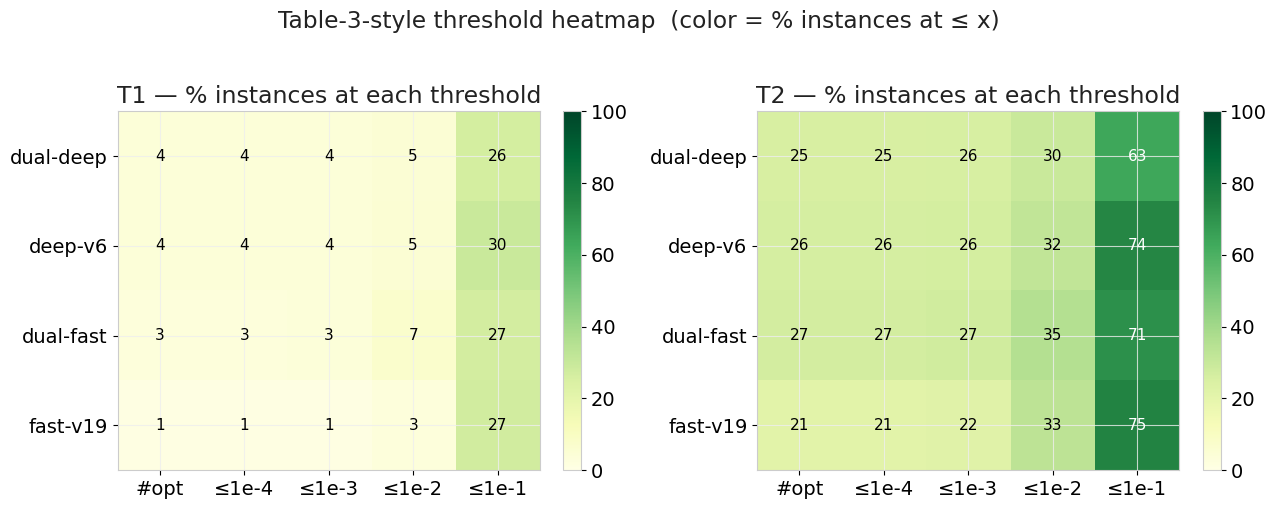

In [3]:
# ## M-02 — Table 3 format heatmap (all 4 solvers)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
thresh_labels = [t[0] for t in THRESHOLDS]
for ax, d in zip(axes, ['T1', 'T2']):
    mat = []
    row_labels = []
    for (agg, name) in [(base4, 'dual-deep'), (imp4, 'deep-v6'),
                         (base5, 'dual-fast'), (imp5, 'fast-v19')]:
        tb = threshold_table(agg[agg.dataset == d])
        n = tb['n'].iloc[0]
        mat.append([tb[l].iloc[0] / n * 100 for l in thresh_labels])
        row_labels.append(name)
    arr = np.array(mat)
    im = ax.imshow(arr, aspect='auto', cmap='YlGn', vmin=0, vmax=100)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f'{arr[i,j]:.0f}', ha='center', va='center',
                    fontsize=11, color='black' if arr[i,j] < 60 else 'white')
    ax.set_xticks(range(len(thresh_labels))); ax.set_xticklabels(thresh_labels)
    ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels)
    ax.set_title(f'{d} — % instances at each threshold')
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle('Table-3-style threshold heatmap  (color = % instances at ≤ x)', y=1.02)
save_show(fig, CHART_DIR, 'M-02-threshold-heatmap.png')


## D2 逐实例胜负

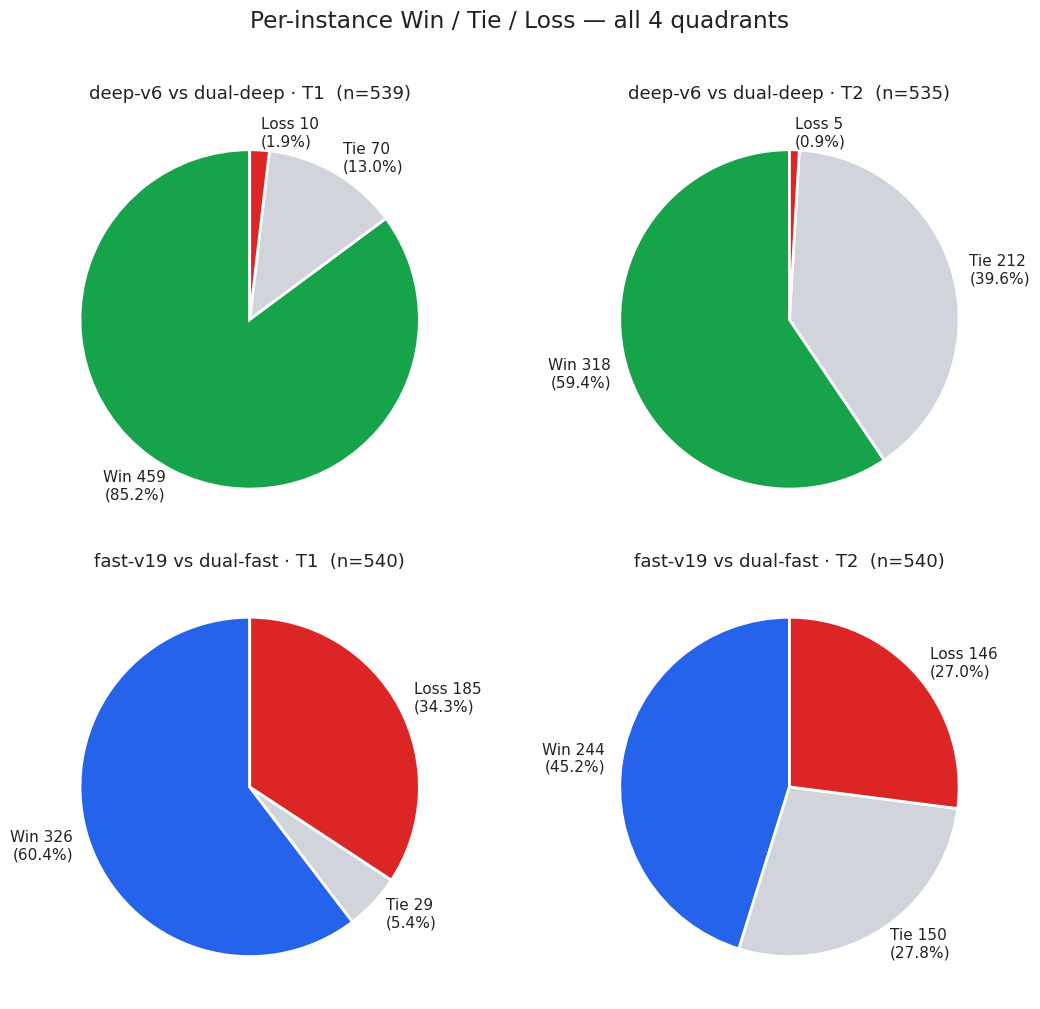

In [4]:
# ## M-03 — Win/Tie/Loss 2×2 pie
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
cells_cfg = [
    (m4, 'T1', 'deep-v6 vs dual-deep · T1', GREEN),
    (m4, 'T2', 'deep-v6 vs dual-deep · T2', GREEN),
    (m5, 'T1', 'fast-v19 vs dual-fast · T1', BLUE),
    (m5, 'T2', 'fast-v19 vs dual-fast · T2', BLUE),
]
for ax, (m, d, ttl, col) in zip(axes.flat, cells_cfg):
    sub = m[m.dataset == d]
    w = (sub.win == 1).sum(); t = (sub.win == 0).sum(); l = (sub.win == -1).sum()
    n = len(sub)
    labels = [f'Win {w}\n({w/n*100:.1f}%)',
              f'Tie {t}\n({t/n*100:.1f}%)',
              f'Loss {l}\n({l/n*100:.1f}%)']
    ax.pie([w, t, l], labels=labels, colors=[col, LIGHT_GRAY, RED], startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2), textprops=dict(fontsize=11))
    ax.set_title(f'{ttl}  (n={n})', fontsize=13)
fig.suptitle('Per-instance Win / Tie / Loss — all 4 quadrants', y=1.01)
save_show(fig, CHART_DIR, 'M-03-win-tie-loss.png')


## D3 因果分解

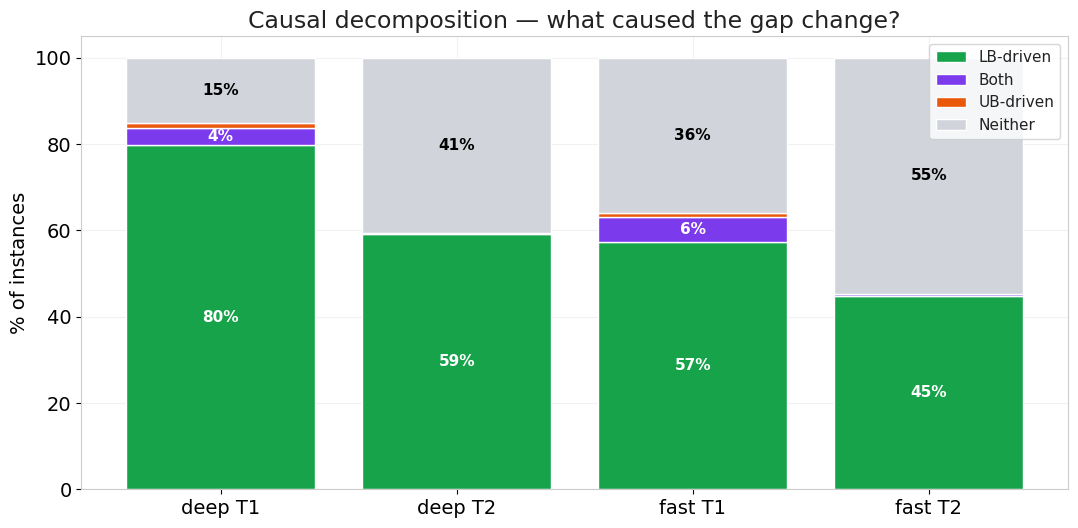

In [5]:
# ## M-04 — Causal decomposition stacked bar
fig, ax = plt.subplots(figsize=(11, 5.5))
cats = ['LB-driven', 'Both', 'UB-driven', 'Neither']
colors = [GREEN, PURPLE, ORANGE, LIGHT_GRAY]
labels_x = ['deep T1', 'deep T2', 'fast T1', 'fast T2']

groups_data = []
for m, d in [(m4, 'T1'), (m4, 'T2'), (m5, 'T1'), (m5, 'T2')]:
    sub = m[m.dataset == d]
    counts = [int((sub.cause == c).sum()) for c in cats]
    n = sum(counts)
    groups_data.append([v/n*100 for v in counts])

arr = np.array(groups_data)
bottoms = np.zeros(len(labels_x))
for i, (c, col) in enumerate(zip(cats, colors)):
    ax.bar(labels_x, arr[:, i], bottom=bottoms, color=col,
           edgecolor='white', linewidth=1, label=c)
    for j, v in enumerate(arr[:, i]):
        if v > 4:
            ax.text(j, bottoms[j] + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=11, color='white' if c != 'Neither' else 'black',
                    fontweight='bold')
    bottoms += arr[:, i]

ax.set_ylabel('% of instances')
ax.set_ylim(0, 105)
ax.set_title('Causal decomposition — what caused the gap change?')
ax.legend(fontsize=11, loc='upper right')
ax.set_axisbelow(True)
save_show(fig, CHART_DIR, 'M-04-causal-decomposition.png')


## D1 (多维) Performance Profile

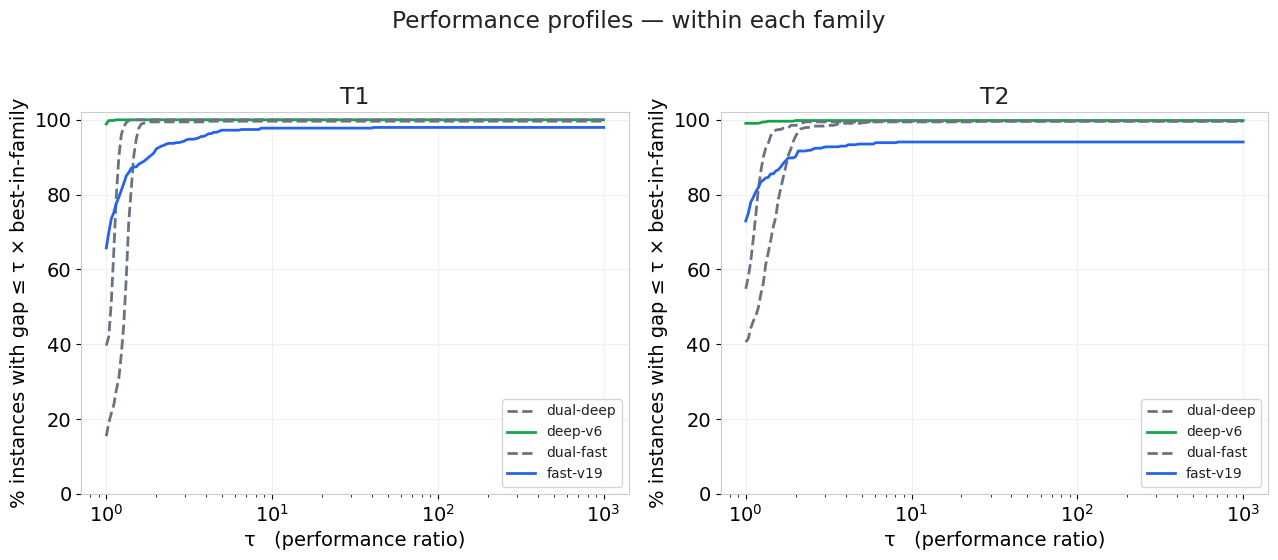

In [6]:
# ## M-05 — Performance Profile (Dolan-Moré style)
# τ=1 时的值 = 在 "每个 instance 上它是最好的" 实例比例
# τ→∞ 时 = 1 (最终都 ≤ τ × best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, d in zip(axes, ['T1', 'T2']):
    imp_gap4 = imp4[imp4.dataset == d].set_index('instance')['gap']
    base_gap4 = base4[base4.dataset == d].set_index('instance')['gap']
    imp_gap5 = imp5[imp5.dataset == d].set_index('instance')['gap']
    base_gap5 = base5[base5.dataset == d].set_index('instance')['gap']
    # align instances present in *all* (for per-family pairs we just need family pair).
    # We'll plot deep family (2 series) and fast family (2 series) independently.
    for sv_name, series, col in [('dual-deep', base_gap4, GRAY),
                                  ('deep-v6',  imp_gap4,  GREEN),
                                  ('dual-fast', base_gap5, GRAY),
                                  ('fast-v19',  imp_gap5,  BLUE)]:
        # pair with its own family's best for performance profile
        if sv_name in ('dual-deep', 'deep-v6'):
            pair = pd.concat([base_gap4, imp_gap4], axis=1, join='inner')
            pair.columns = ['a', 'b']
            best = pair.min(axis=1)
            r = (series.reindex(pair.index) / best.replace(0, np.nan)).dropna()
        else:
            pair = pd.concat([base_gap5, imp_gap5], axis=1, join='inner')
            pair.columns = ['a', 'b']
            best = pair.min(axis=1)
            r = (series.reindex(pair.index) / best.replace(0, np.nan)).dropna()
        # Special case: both zero -> both optimal -> ratio = 1 (solved)
        # We pre-filter: best==0 rows -> if series==0 ratio=1 else =inf
        both_zero = (best == 0) & (series.reindex(pair.index) == 0)
        if sv_name in ('dual-deep','deep-v6'):
            r = series.reindex(pair.index).copy()
            ratios = []
            for inst, val in r.items():
                b = best.loc[inst]
                if b == 0 and val == 0: ratios.append(1.0)
                elif b == 0: ratios.append(np.inf)
                else: ratios.append(val / b)
            r = pd.Series(ratios, index=r.index)
        else:
            r = series.reindex(pair.index).copy()
            ratios = []
            for inst, val in r.items():
                b = best.loc[inst]
                if b == 0 and val == 0: ratios.append(1.0)
                elif b == 0: ratios.append(np.inf)
                else: ratios.append(val / b)
            r = pd.Series(ratios, index=r.index)
        taus = np.logspace(0, 3, 200)
        y = [(r <= t).mean() * 100 for t in taus]
        marker = 's' if sv_name in ('deep-v6','fast-v19') else 'o'
        ls = '--' if sv_name.startswith('dual-') else '-'
        ax.plot(taus, y, color=col, linestyle=ls, linewidth=2, label=sv_name)
    ax.set_xscale('log')
    ax.set_xlabel('τ   (performance ratio)')
    ax.set_ylabel('% instances with gap ≤ τ × best-in-family')
    ax.set_title(f'{d}')
    ax.set_ylim(0, 102)
    ax.legend(fontsize=10, loc='lower right')
    ax.set_axisbelow(True)
fig.suptitle('Performance profiles — within each family', y=1.02)
save_show(fig, CHART_DIR, 'M-05-performance-profile.png')


## D6 时序

/home/ylzl/WMDS26/report/_style.py:159: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.931291 0.965549 0.832014 ... 0.537169 0.60264  0.557072]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[mask, c] = sub.loc[mask, "gap"]
/home/ylzl/WMDS26/report/_style.py:159: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.810692 0.827107 0.804142 ... 0.479776 0.537682 0.496115]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sub.loc[mask, c] = sub.loc[mask, "gap"]
/home/ylzl/WMDS26/report/_style.py:159: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.13585  0.131756 0.159044 ... 0.077471 0.068272 0.101045]' has dtype incompatible with int64, please explicitly

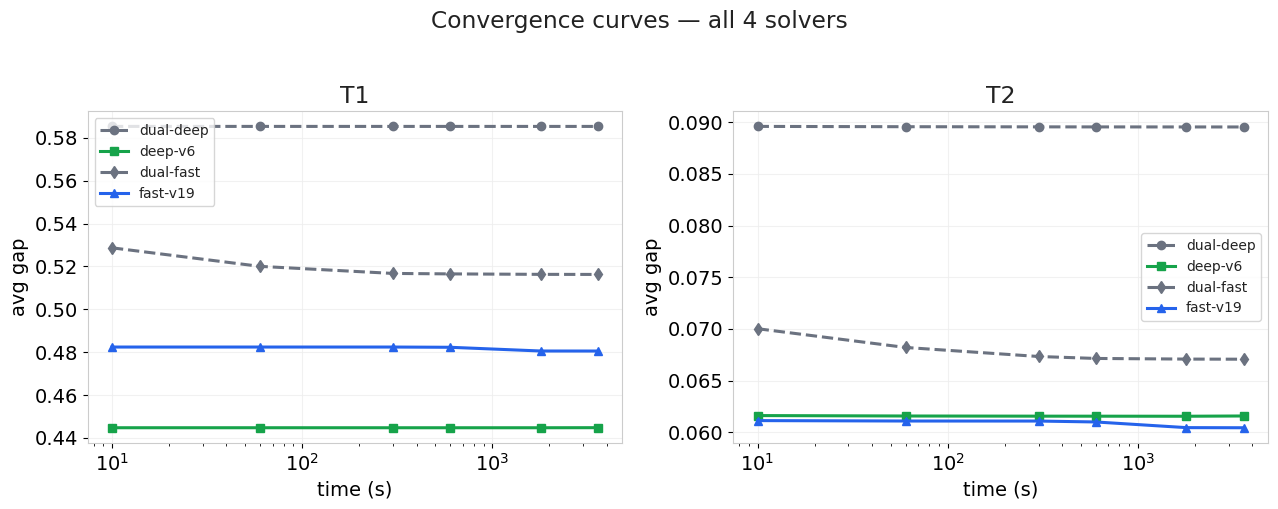

In [7]:
# ## M-06 — Convergence curves, 4 solvers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, d in zip(axes, ['T1', 'T2']):
    for sv, col, marker in [('dual-deep', GRAY, 'o'),
                             ('deep-v6',  GREEN, 's'),
                             ('dual-fast', GRAY, 'd'),
                             ('fast-v19',  BLUE,  '^')]:
        dfx = df4 if sv in ('dual-deep','deep-v6') else df5
        ts, ys = gap_curve(dfx, sv, d)
        ls = '--' if sv.startswith('dual-') else '-'
        ax.plot(ts, ys, color=col, linestyle=ls, linewidth=2.2, marker=marker,
                label=sv)
    ax.set_xscale('log')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('avg gap')
    ax.set_title(d)
    ax.legend(fontsize=10)
    ax.set_axisbelow(True)
fig.suptitle('Convergence curves — all 4 solvers', y=1.02)
save_show(fig, CHART_DIR, 'M-06-convergence.png')
